In [2]:
from pathlib import Path
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.utils import image_dataset_from_directory
from collections import OrderedDict
import matplotlib.pyplot as plt

# ====================================================
# 1. Global config
# ====================================================

IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 123

root_dir = Path(
    "/data/users/zhouz6436/"
    "Pneumonia_image_classification/"
    "chest_xray_3class"
)

train_dir = root_dir / "train"
test_dir = root_dir / "test"

model_dir = root_dir.parent / "models"
model_dir.mkdir(
    parents=True,
    exist_ok=True
)

AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

I0000 00:00:1786725171.422046 1085320 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1786725171.472160 1085320 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1786725172.830284 1085320 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [3]:
# ====================================================
# 2. Preprocess and prepare helper
# ====================================================

def preprocess(image, label):
    image = tf.cast(
        image,
        tf.float32
    )

    image = (
        tf.keras.applications
        .mobilenet_v2
        .preprocess_input(image)
    )

    return image, label


def prepare(
    dataset,
    shuffle=False
):
    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=1000,
            seed=SEED,
            reshuffle_each_iteration=True
        )

    dataset = dataset.map(
        preprocess,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset

In [4]:
# ====================================================
# 3. Load three-class datasets
# ====================================================

train_full = image_dataset_from_directory(
    train_dir,
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),
    shuffle=True,
    seed=SEED,
    batch_size=None,
)

test_raw = image_dataset_from_directory(
    test_dir,
    image_size=(
        IMG_SIZE,
        IMG_SIZE
    ),
    shuffle=False,
    batch_size=None,
)

class_names = train_full.class_names
test_class_names = test_raw.class_names
num_classes = len(class_names)

expected_classes = [
    "NORMAL",
    "bacteria",
    "virus"
]

print(
    "Training classes:",
    class_names
)

print(
    "Test classes:",
    test_class_names
)

print(
    "Number of classes:",
    num_classes
)

assert class_names == expected_classes, (
    f"Expected {expected_classes}, "
    f"but found {class_names}"
)

assert test_class_names == class_names, (
    "Training and test class orders "
    "do not match"
)

Found 5232 files belonging to 3 classes.
Found 624 files belonging to 3 classes.
Training classes: ['NORMAL', 'bacteria', 'virus']
Test classes: ['NORMAL', 'bacteria', 'virus']
Number of classes: 3


E0000 00:00:1786725178.647454 1085320 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [5]:
# ====================================================
# 4. Training/validation split
# ====================================================

total = (
    train_full
    .cardinality()
    .numpy()
)

val_size = int(
    0.10 * total
)

train_size = (
    total - val_size
)

train_raw = train_full.take(
    train_size
)

val_raw = train_full.skip(
    train_size
)

print(
    "Total images:",
    total
)

print(
    "Training images:",
    train_size
)

print(
    "Validation images:",
    val_size
)

total_train = (
    train_raw
    .cardinality()
    .numpy()
)


def make_subset_B(fraction):
    number_of_images = max(
        1,
        int(
            total_train
            * fraction
        )
    )

    subset_raw = train_raw.take(
        number_of_images
    )

    print(
        f"{int(fraction * 100)}% subset:",
        number_of_images,
        "images"
    )

    return prepare(
        subset_raw,
        shuffle=True
    )


train_10 = make_subset_B(0.10)
train_25 = make_subset_B(0.25)
train_50 = make_subset_B(0.50)

train_100 = prepare(
    train_raw,
    shuffle=True
)

val = prepare(
    val_raw,
    shuffle=False
)

test = prepare(
    test_raw,
    shuffle=False
)

for images, labels in test.take(1):
    print(
        "Test image shape:",
        images.shape
    )

    print(
        "Test label shape:",
        labels.shape
    )

    print(
        "First test labels:",
        labels.numpy()
    )

Total images: 5232
Training images: 4709
Validation images: 523
10% subset: 470 images
25% subset: 1177 images
50% subset: 2354 images
Test image shape: (32, 224, 224, 3)
Test label shape: (32,)
First test labels: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [6]:
# ====================================================
# 5. Model B:
# ImageNet MobileNetV2 frozen backbone
# ====================================================

def make_backbone_B():
    backbone = (
        tf.keras.applications
        .MobileNetV2(
            input_shape=(
                IMG_SIZE,
                IMG_SIZE,
                3
            ),
            include_top=False,
            weights="imagenet",
            pooling=None,
        )
    )

    backbone.trainable = False

    return backbone


def make_classifier_B():
    backbone = make_backbone_B()

    inputs = tf.keras.Input(
        shape=(
            IMG_SIZE,
            IMG_SIZE,
            3
        )
    )

    x = backbone(
        inputs,
        training=False
    )

    x = layers.GlobalAveragePooling2D()(
        x
    )

    x = layers.Dense(
        128,
        activation="relu"
    )(x)

    x = layers.Dropout(
        0.30
    )(x)

    outputs = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = models.Model(
        inputs=inputs,
        outputs=outputs
    )

    model.compile(
        optimizer=(
            tf.keras.optimizers.Adam(
                learning_rate=1e-4
            )
        ),
        loss=(
            "sparse_categorical_"
            "crossentropy"
        ),
        metrics=["accuracy"]
    )

    return model


model_B = make_classifier_B()
model_B.summary()

assert model_B.output_shape[-1] == 3


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
# ====================================================
# 6. Train Model B
# ====================================================

EPOCHS = 20

b_subsets = OrderedDict({
    "10%": train_10,
    "25%": train_25,
    "50%": train_50,
    "100%": train_100,
})

histories_B = {}
tests_B = {}
models_B = OrderedDict()

for name, subset_dataset in (
    b_subsets.items()
):
    print(
        f"\n=== Model B three-class "
        f"training: {name} subset ==="
    )

    tf.keras.backend.clear_session()

    tf.keras.utils.set_random_seed(
        SEED
    )

    model = make_classifier_B()

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        )
    ]

    history = model.fit(
        subset_dataset,
        epochs=EPOCHS,
        validation_data=val,
        callbacks=callbacks,
        verbose=1
    )

    test_metrics = model.evaluate(
        test,
        return_dict=True,
        verbose=1
    )

    histories_B[name] = (
        history.history
    )

    tests_B[name] = test_metrics
    models_B[name] = model

    fraction_name = name.replace(
        "%",
        "pct"
    )

    weights_path = (
        model_dir
        / (
            "model_B_3class_"
            f"{fraction_name}"
            ".weights.h5"
        )
    )

    model.save_weights(
        weights_path
    )

    print(
        "Saved Model B weights:",
        weights_path
    )

print(
    "\nModel B three-class "
    "test metrics:"
)

for name, metrics in tests_B.items():
    print(
        name,
        metrics
    )


=== Model B three-class training: 10% subset ===
Epoch 1/20


/data/users/zhouz6436/miniconda3/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


15/15 ━━━━━━━━━━━━━━━━━━━━ 12s 594ms/step - accuracy: 0.4723 - loss: 1.0891 - val_accuracy: 0.4952 - val_loss: 0.9906
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 515ms/step - accuracy: 0.5255 - loss: 0.9463 - val_accuracy: 0.6902 - val_loss: 0.8151
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 521ms/step - accuracy: 0.6106 - loss: 0.8645 - val_accuracy: 0.7228 - val_loss: 0.7191
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 511ms/step - accuracy: 0.6191 - loss: 0.8058 - val_accuracy: 0.6979 - val_loss: 0.7023
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step - accuracy: 0.6766 - loss: 0.7142 - val_accuracy: 0.7304 - val_loss: 0.6855
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 502ms/step - accuracy: 0.7043 - loss: 0.6732 - val_accuracy: 0.7648 - val_loss: 0.6022
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 8s 508ms/step - accuracy: 0.7383 - loss: 0.6180 - val_accuracy: 0.7170 - val_loss: 0.6494
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 7s 500ms/step - accuracy: 0.7404 - loss: 0.6154 - val_accuracy: 0.7533 - val

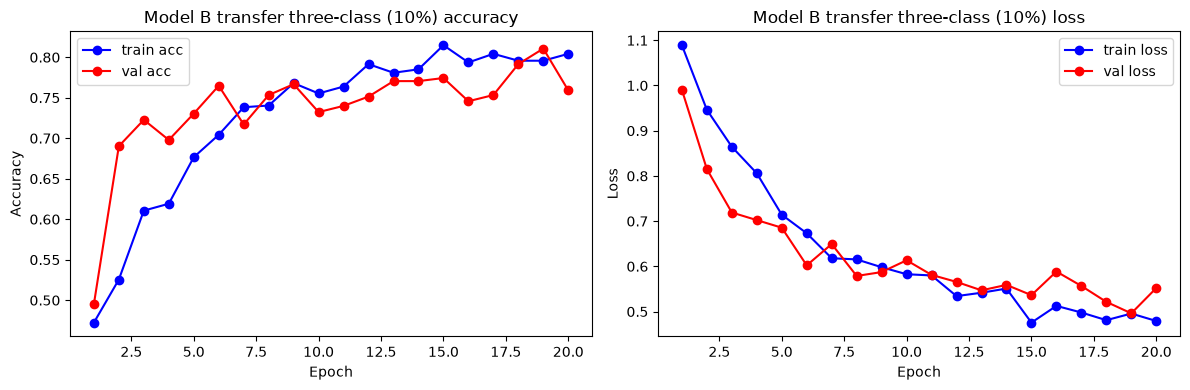

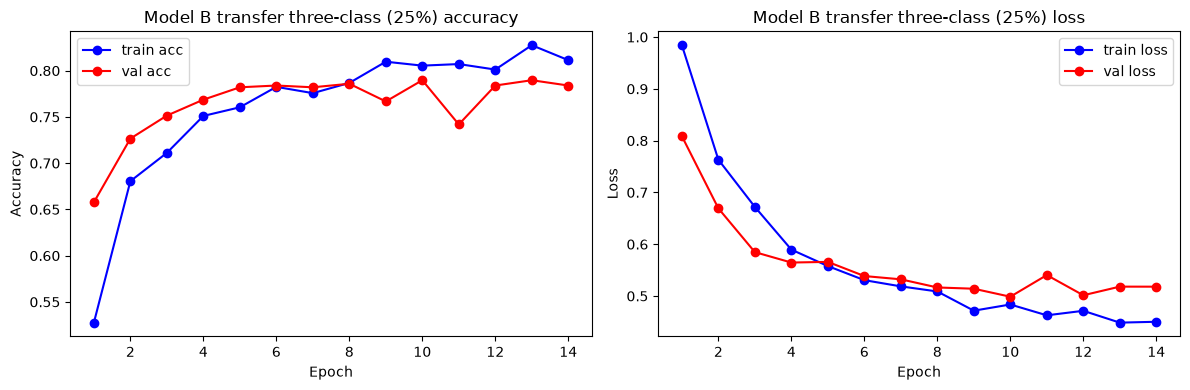

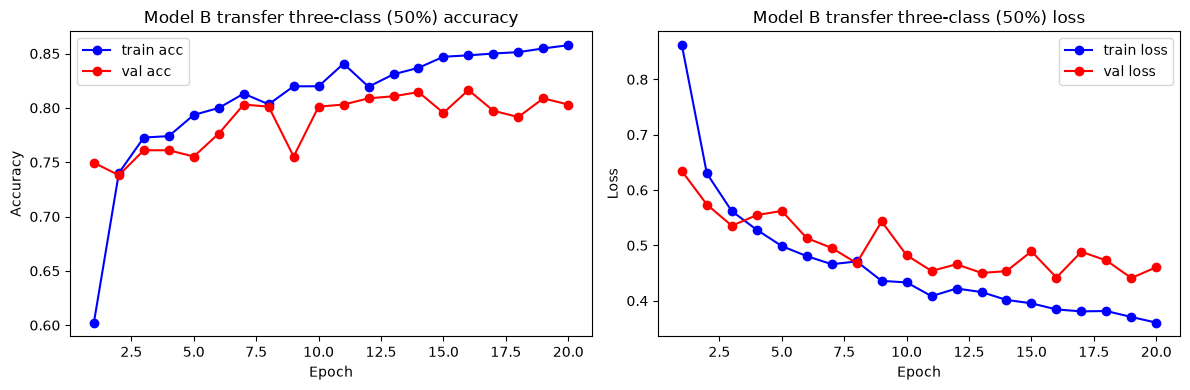

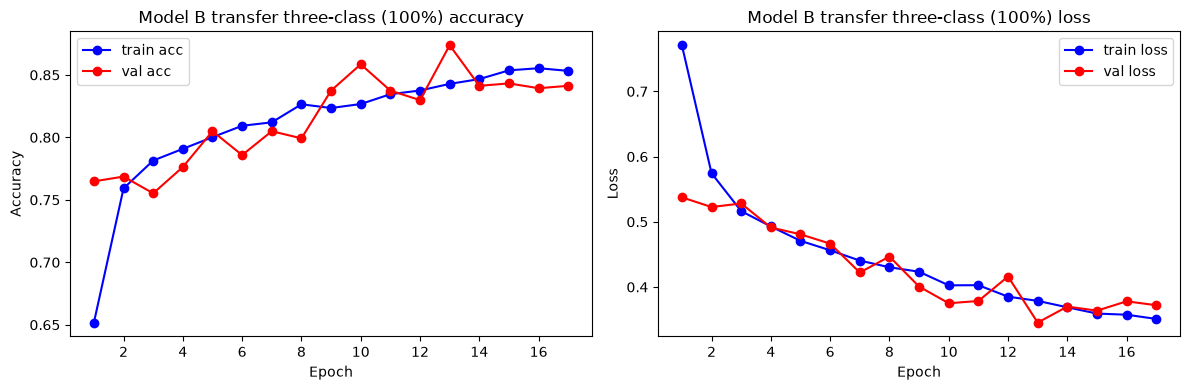

In [8]:
class HistoryWrapper:
    def __init__(self, hist_dict):
        self.history = hist_dict

def plot_history(history, title_prefix="Model"):
    acc     = history.history.get("accuracy", [])
    val_acc = history.history.get("val_accuracy", [])
    loss    = history.history.get("loss", [])
    val_loss= history.history.get("val_loss", [])

    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    if len(acc) > 0:
        epochs_acc = range(1, len(acc) + 1)
        plt.plot(epochs_acc, acc, "bo-", label="train acc")
    if len(val_acc) > 0:
        epochs_val_acc = range(1, len(val_acc) + 1)
        plt.plot(epochs_val_acc, val_acc, "ro-", label="val acc")
    plt.title(f"{title_prefix} accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    if len(loss) > 0:
        epochs_loss = range(1, len(loss) + 1)
        plt.plot(epochs_loss, loss, "bo-", label="train loss")
    if len(val_loss) > 0:
        epochs_val_loss = range(1, len(val_loss) + 1)
        plt.plot(epochs_val_loss, val_loss, "ro-", label="val loss")
    plt.title(f"{title_prefix} loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()
    
for fraction, history_dict in (
    histories_B.items()
):
    plot_history(
        HistoryWrapper(
            history_dict
        ),
        title_prefix=(
            "Model B transfer "
            "three-class "
            f"({fraction})"
        )
    )

In [9]:
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# ====================================================
# 8. Three-class evaluation
# ====================================================

y_true_batches = []

for _, labels in test_raw:
    y_true_batches.append(
        labels
        .numpy()
        .ravel()
    )

y_true = np.concatenate(
    y_true_batches,
    axis=0
)

label_indices = list(
    range(num_classes)
)

print("Class mapping:")

for index, class_name in enumerate(
    class_names
):
    print(
        index,
        "=",
        class_name
    )

print("\nTrue-label counts:")

for index, class_name in enumerate(
    class_names
):
    print(
        class_name,
        ":",
        int(
            np.sum(
                y_true == index
            )
        )
    )


for name, model in models_B.items():
    print(
        f"\n=== Model B evaluation: "
        f"{name} subset ==="
    )

    probabilities = model.predict(
        test,
        verbose=1
    )

    y_pred = np.argmax(
        probabilities,
        axis=1
    )

    print(
        "Predicted-label counts:"
    )

    for index, class_name in enumerate(
        class_names
    ):
        print(
            class_name,
            ":",
            int(
                np.sum(
                    y_pred == index
                )
            )
        )

    print(
        "\nClassification report:"
    )

    print(
        classification_report(
            y_true,
            y_pred,
            labels=label_indices,
            target_names=class_names,
            digits=4,
            zero_division=0
        )
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=label_indices
    )

    print("Confusion matrix:")
    print(matrix)

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            y_pred
        )
    )

    macro_f1 = f1_score(
        y_true,
        y_pred,
        average="macro",
        zero_division=0
    )

    print(
        "Balanced accuracy:",
        round(
            balanced_accuracy,
            4
        )
    )

    print(
        "Macro F1:",
        round(
            macro_f1,
            4
        )
    )

Class mapping:
0 = NORMAL
1 = bacteria
2 = virus

True-label counts:
NORMAL : 234
bacteria : 242
virus : 148

=== Model B evaluation: 10% subset ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 187ms/step
Predicted-label counts:
NORMAL : 185
bacteria : 312
virus : 127

Classification report:
              precision    recall  f1-score   support

      NORMAL     0.9622    0.7607    0.8496       234
    bacteria     0.7500    0.9669    0.8448       242
       virus     0.7323    0.6284    0.6764       148

    accuracy                         0.8093       624
   macro avg     0.8148    0.7853    0.7903       624
weighted avg     0.8254    0.8093    0.8067       624

Confusion matrix:
[[178  25  31]
 [  5 234   3]
 [  2  53  93]]
Balanced accuracy: 0.7853
Macro F1: 0.7903

=== Model B evaluation: 25% subset ===
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 189ms/step
Predicted-label counts:
NORMAL : 186
bacteria : 293
virus : 145

Classification report:
              precision    recall  f1-score   support

      NORM